[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\huawei\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.68      0.73     19329
     neutral       0.30      0.02      0.03      6352
    positive       0.84      0.97      0.90     57073

    accuracy                           0.83     82754
   macro avg       0.64      0.56      0.55     82754
weighted avg       0.79      0.83      0.79     82754



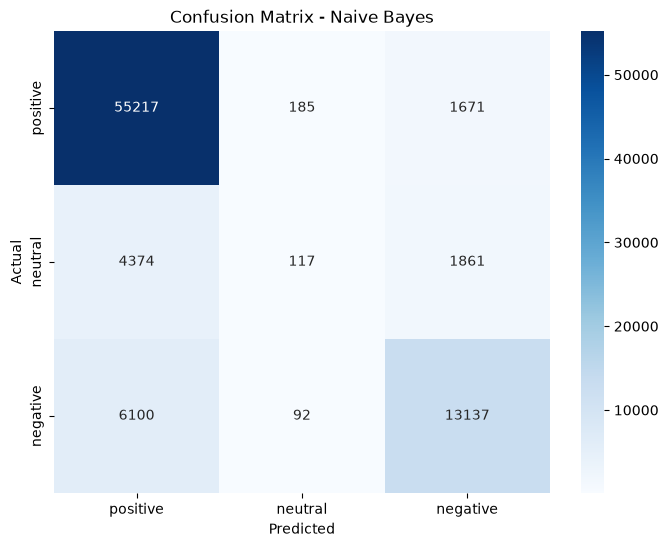

In [15]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

data = pd.read_csv(r'C:\Users\huawei\NLP labs\Amazon_Unlocked_Mobile.csv')
data = data.dropna(subset=['Reviews', 'Rating'])

def get_sentiment(rating):
    if rating > 3:
        return 'positive'
    elif rating < 3:
        return 'negative'
    else:
        return 'neutral'

data['Sentiment'] = data['Rating'].apply(get_sentiment)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

data['Cleaned_Review'] = data['Reviews'].apply(preprocess_text)

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Cleaned_Review'], data['Sentiment'], test_size=0.2, random_state=42
)

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

predictions = nb_classifier.predict(test_vectors)

accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(classification_report(test_labels, predictions))

cm = confusion_matrix(test_labels, predictions, labels=['positive', 'neutral', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['positive', 'neutral', 'negative'], 
            yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()